In [12]:
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.plotting import plot_anat, plot_roi
from nilearn.image import load_img, math_img


subject_id = "sub-05"
base_path = "/ptmp/hmueller2/Downloads/ibc_preprocessed"

# File paths (update these to match your actual file locations)
t1_file = f"{base_path}/{subject_id}/ses-00/anat/{subject_id}_ses-00_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz"
gm_prob_file = f"{base_path}/{subject_id}/ses-00/anat/{subject_id}_ses-00_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz"
wm_prob_file = f"{base_path}/{subject_id}/ses-00/anat/{subject_id}_ses-00_space-MNI152NLin2009cAsym_label-WM_probseg.nii.gz"

/home/hmueller2/.local/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:559: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(anat_img, ensure_finite=True)
/home/hmueller2/.local/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:232: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(img, ensure_finite=True)


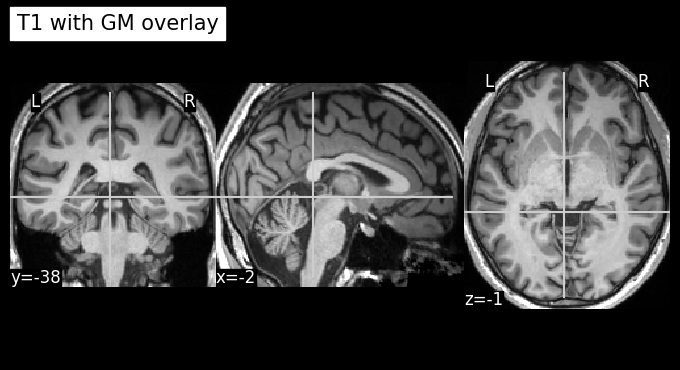

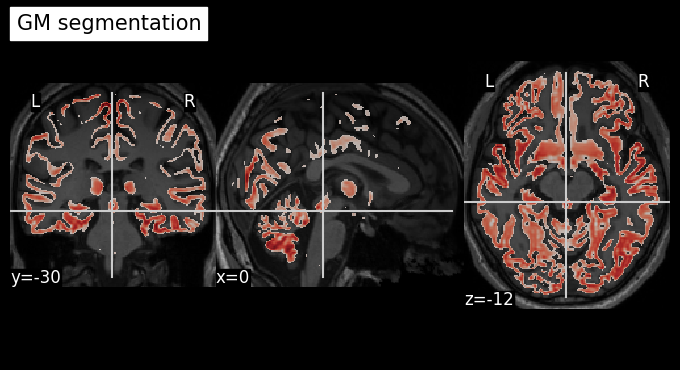

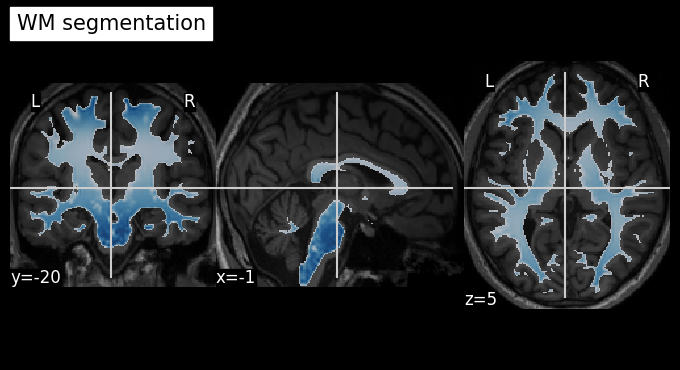

In [17]:
# Plot T1 with GM overlay
plot_anat(t1_file, title='T1 with GM overlay', display_mode='ortho', dim=-1)
plot_roi(gm_prob_file, bg_img=t1_file, title='GM segmentation', display_mode='ortho', cmap='Reds')

# Plot T1 with WM overlay
plot_roi(wm_prob_file, bg_img=t1_file, title='WM segmentation', display_mode='ortho', cmap='Blues')

plt.show()

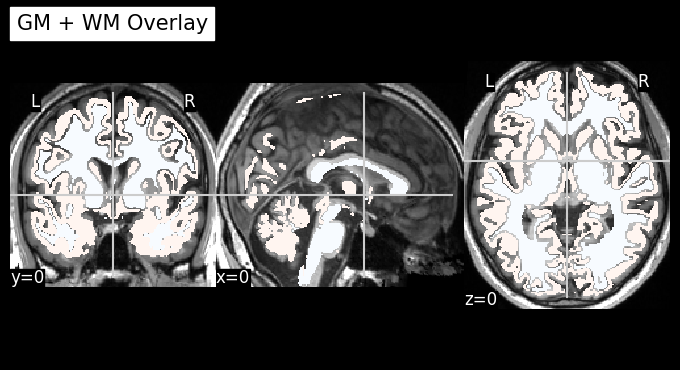

In [ ]:
# Load and threshold probabilistic segmentations to create binary masks
gm_mask = math_img("img > 0.5", img=gm_prob_file)
wm_mask = math_img("img > 0.5", img=wm_prob_file)

# Save GM overlay
plot_roi(gm_mask, bg_img=t1_file, title='GM Mask', cmap='Reds',
         output_file='gm_overlay.png', display_mode='ortho', cut_coords=(0, 0, 0))

# Save WM overlay
plot_roi(wm_mask, bg_img=t1_file, title='WM Mask', cmap='Blues',
         output_file='wm_overlay.png', display_mode='ortho', cut_coords=(0, 0, 0))

# Combined overlay with both GM and WM
display = plot_anat(t1_file, title="GM + WM Overlay",
                    display_mode='ortho', dim=-1, cut_coords=(0, 0, 0))
display.add_overlay(gm_mask, cmap='Reds')
display.add_overlay(wm_mask, cmap='Blues')

# Save the combined overlay as an image
#plt.savefig('gm_wm_overlay.png')